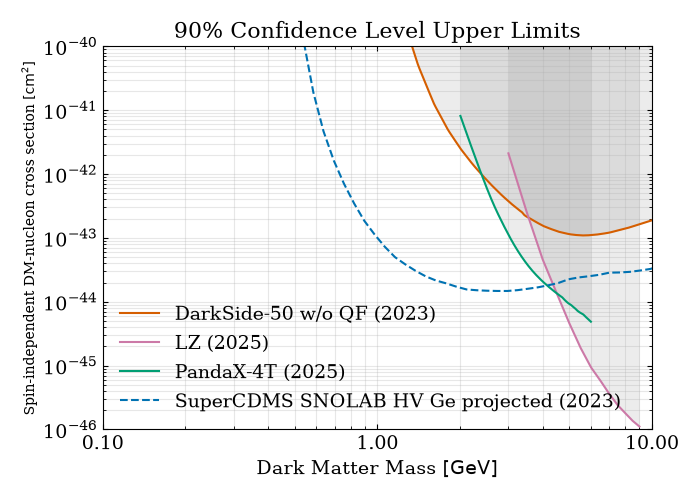

In [17]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

%matplotlib widget

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

# DarkSide-50
ds50 = np.loadtxt('../curves/PhysRevD.107.063001/outputs/darkside50_NQ_limit.csv',
                  delimiter=',', skiprows=1)

# LZ (from HEPData YAML)
with open('../curves/2512.08065v2/HEPData-ins3091049-v2-SI_cross_section.yaml') as f:
    lz_raw = yaml.safe_load(f)
lz_mass  = np.array([v['value'] for v in lz_raw['independent_variables'][0]['values']])
lz_limit = np.array([v['value'] for v in lz_raw['dependent_variables'][0]['values']])

# PandaX-4T
panda = np.loadtxt('../curves/panda/outputs/pandax4t_2025.csv',
                   delimiter=',', skiprows=1)

# SuperCDMS SNOLAB HV projected limit (arXiv:2203.08463)
scdms_hv = np.loadtxt('../curves/matlab/outputs/scdms_hv_cd2_p90median.csv',
                      delimiter=',', skiprows=1)

Y_TOP = 1e-40  # matches ax.set_ylim upper bound

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ds50[:, 0],  ds50[:, 1],  color='#D55E00', lw=1.5, ls='-',  label='DarkSide-50 w/o QF (2023)')
ax.fill_between(ds50[:, 0], ds50[:, 1], Y_TOP, color='gray', alpha=0.15, lw=0)

ax.plot(lz_mass,     lz_limit,    color='#CC79A7', lw=1.5, ls='-',  label='LZ (2025)')
ax.fill_between(lz_mass, lz_limit, Y_TOP, color='gray', alpha=0.15, lw=0)

ax.plot(panda[:, 0], panda[:, 1], color='#009E73', lw=1.5, ls='-',  label='PandaX-4T (2025)')
ax.fill_between(panda[:, 0], panda[:, 1], Y_TOP, color='gray', alpha=0.15, lw=0)

ax.plot(scdms_hv[:, 0], scdms_hv[:, 1], color='#0072B2', lw=1.5, ls='--', label='SuperCDMS SNOLAB HV Ge projected (2023)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-1, 10.0)
ax.set_ylim(1e-46, Y_TOP)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xlabel(r'Dark Matter Mass $[\mathrm{GeV}]$')
ax.set_ylabel(r'Spin-independent DM-nucleon cross section $[\mathrm{cm}^2]$', fontsize=10)

ax.set_title(r'90$\%$ Confidence Level Upper Limits', fontsize=16)
ax.legend(frameon=False)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

fig.savefig('../plots/SuperCDMS_SNOLAB_focused_comparison/dm_limits_comparison.pdf')
fig.savefig('../plots/SuperCDMS_SNOLAB_focused_comparison/dm_limits_comparison.png')
plt.show()